<a href="https://colab.research.google.com/github/KaranYadav6041/SRM-AIML-D-RA2411026030211-/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [30]:
df= pd.read_csv("/content/knn_customer_dataset_240_rows.csv")
df.head()

,Customer_ID,Age,Annual_Spending_k,target
0,C025,41,67.9,High Value
1,C007,38,58.0,Low Value
2,C094,58,62.0,High Value
3,C110,54,92.8,High Value
4,C105,56,63.1,Low Value


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        240 non-null    object 
 1   Age                240 non-null    int64  
 2   Annual_Spending_k  240 non-null    float64
 3   target             240 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 7.6+ KB


In [32]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Annual_Spending_k,0
target,0


In [33]:
target_column= "target"

X=df.drop(columns=[target_column])
y=df[target_column]

X.head()
y.head()
y.value_counts()

,count
target,
Low Value,126
High Value,114


In [34]:
X=X.select_dtypes(include=np.number)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (192, 2)
Testing Data: (48, 2)


In [35]:
scaler=StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [36]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [37]:
y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9166666666666666


In [38]:
print("Classification Report:", classification_report(y_test, y_pred))

Classification Report:               precision    recall  f1-score   support

  High Value       0.88      0.96      0.92        23
   Low Value       0.96      0.88      0.92        25

    accuracy                           0.92        48
   macro avg       0.92      0.92      0.92        48
weighted avg       0.92      0.92      0.92        48



In [39]:
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

Confusion Matrix: [[22  1]
 [ 3 22]]


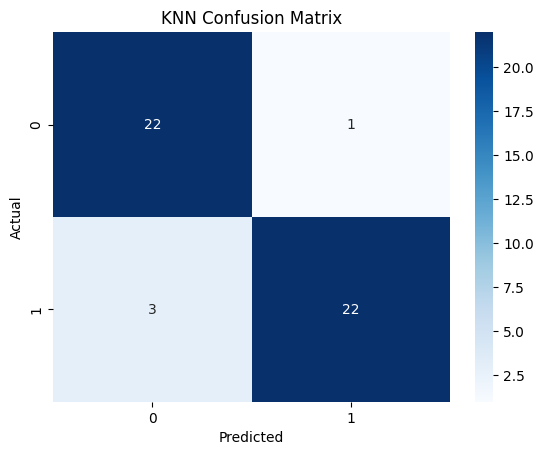

In [40]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

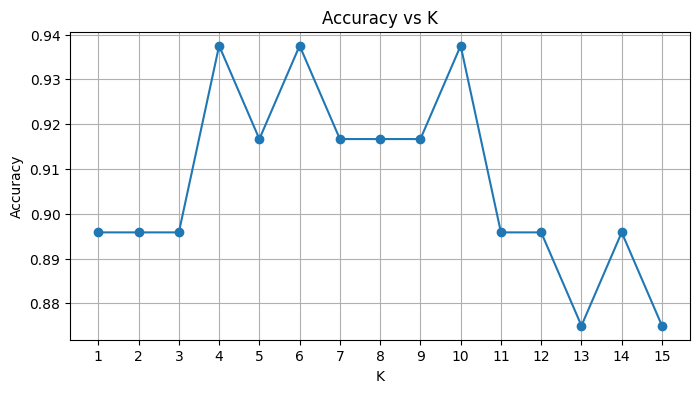

In [41]:
k_values = range(1, 16)
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    accuracy_scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracy_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()